<a href="https://colab.research.google.com/github/fazmina11/fazmina-codeboosters-2026/blob/main/Day5/Mini_project_Day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn requests joblib

In [ ]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
cities = {
    "Chennai": (13.0827, 80.2707),
    "Mumbai": (19.0760, 72.8777),
    "Kolkata": (22.5726, 88.3639),
    "Delhi": (28.6139, 77.2090),
    "Bangalore": (12.9716, 77.5946),
    "Hyderabad": (17.3850, 78.4867),
    "Pune": (18.5204, 73.8567),
    "Ahmedabad": (23.0225, 72.5714)
}

In [ ]:
all_data = []

for city, (lat, lon) in cities.items():

    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m"
    )

    response = requests.get(url)

    data = response.json()

    temp = data["hourly"]["temperature_2m"]
    humidity = data["hourly"]["relative_humidity_2m"]
    wind = data["hourly"]["wind_speed_10m"]
    times = data["hourly"]["time"]

    city_df = pd.DataFrame({
        "city": city,
        "time": times,
        "temperature": temp,
        "humidity": humidity,
        "wind_speed": wind
    })

    all_data.append(city_df)

weather_df = pd.concat(all_data, ignore_index=True)

weather_df.head()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
print("Rows:", weather_df.shape[0])
print("Columns:", weather_df.shape[1])

weather_df.info()

NameError: name 'weather_df' is not defined

In [ ]:
weather_df.to_csv(
    "weather_raw.csv",
    index=False
)

print("Raw dataset saved")

Raw dataset saved


In [ ]:
weather_df.drop_duplicates(inplace=True)

weather_df.dropna(inplace=True)

weather_df["time"] = pd.to_datetime(
    weather_df["time"]
)

weather_df.head()

,city,time,temperature,humidity,wind_speed
0,Chennai,2026-05-30 00:00:00,29.7,59,11.7
1,Chennai,2026-05-30 01:00:00,30.1,57,10.7
2,Chennai,2026-05-30 02:00:00,31.5,54,13.0
3,Chennai,2026-05-30 03:00:00,33.5,49,12.7
4,Chennai,2026-05-30 04:00:00,35.5,44,8.0


In [ ]:
weather_df.isnull().sum()

,0
city,0
time,0
temperature,0
humidity,0
wind_speed,0


In [ ]:
weather_df.to_csv(
    "weather_clean.csv",
    index=False
)

print("Clean dataset saved")

Clean dataset saved


In [ ]:
conn = sqlite3.connect(
    "weather.db"
)

weather_df.to_sql(
    "weather",
    conn,
    if_exists="replace",
    index=False
)

print("Database created")

Database created


In [ ]:
query = """
SELECT city,
AVG(temperature) AS avg_temp
FROM weather
GROUP BY city
"""

result = pd.read_sql(
    query,
    conn
)

result

,city,avg_temp
0,Ahmedabad,33.364286
1,Bangalore,24.078571
2,Chennai,31.546429
3,Delhi,31.997619
4,Hyderabad,30.960714
5,Kolkata,30.925000
6,Mumbai,30.400000
7,Pune,28.445833


In [ ]:
query = """
SELECT city,
AVG(humidity) AS avg_humidity
FROM weather
GROUP BY city
ORDER BY avg_humidity DESC
"""

pd.read_sql(query, conn)

,city,avg_humidity
0,Bangalore,82.410714
1,Kolkata,78.000000
2,Mumbai,72.410714
3,Pune,66.285714
4,Chennai,65.476190
5,Ahmedabad,56.761905
6,Hyderabad,52.994048
7,Delhi,48.922619


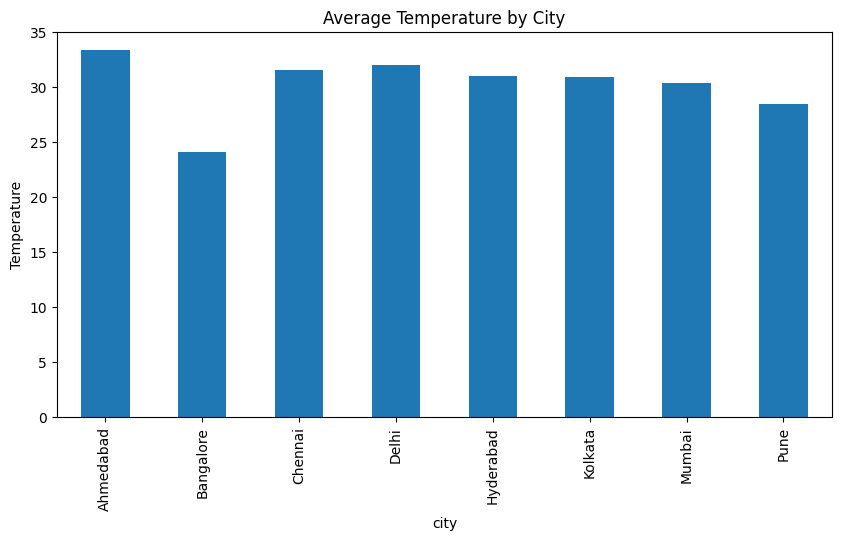

In [ ]:
city_temp = weather_df.groupby(
    "city"
)["temperature"].mean()

plt.figure(figsize=(10,5))

city_temp.plot(kind="bar")

plt.title("Average Temperature by City")

plt.ylabel("Temperature")

plt.show()

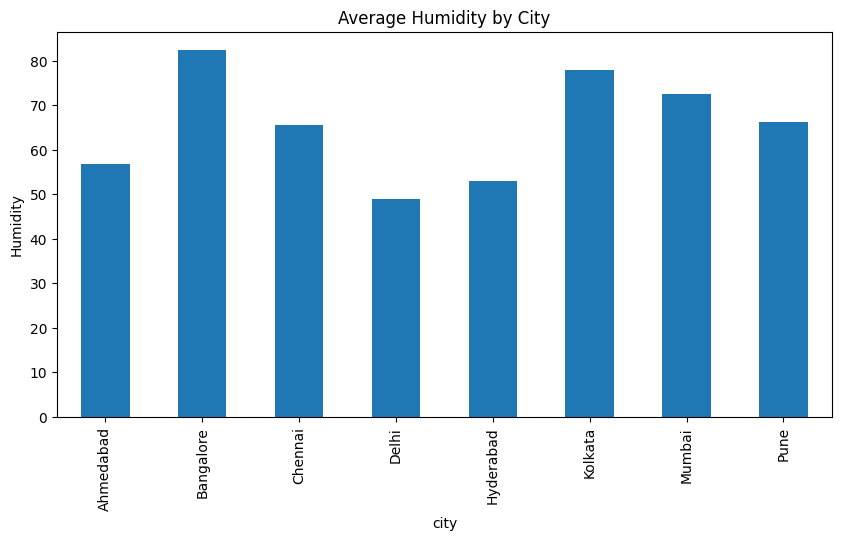

In [ ]:
city_humidity = weather_df.groupby(
    "city"
)["humidity"].mean()

plt.figure(figsize=(10,5))

city_humidity.plot(kind="bar")

plt.title("Average Humidity by City")

plt.ylabel("Humidity")

plt.show()

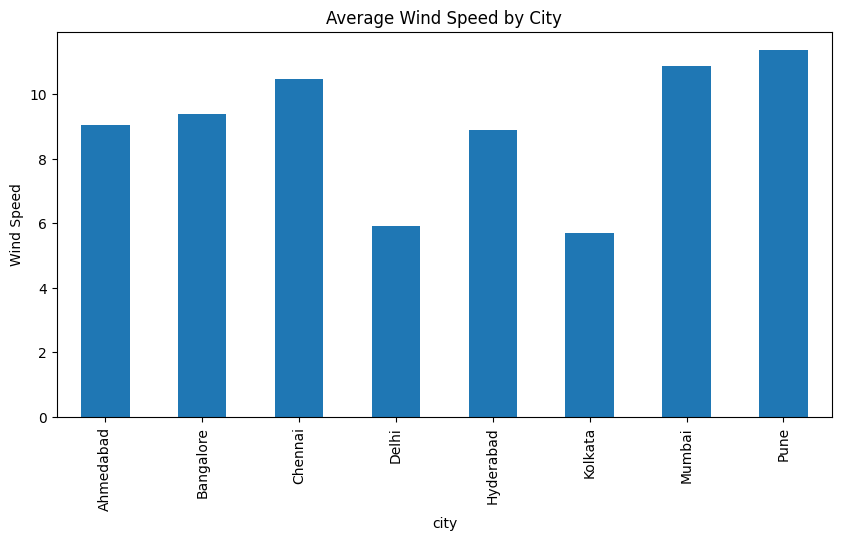

In [ ]:
city_wind = weather_df.groupby(
    "city"
)["wind_speed"].mean()

plt.figure(figsize=(10,5))

city_wind.plot(kind="bar")

plt.title("Average Wind Speed by City")

plt.ylabel("Wind Speed")

plt.show()

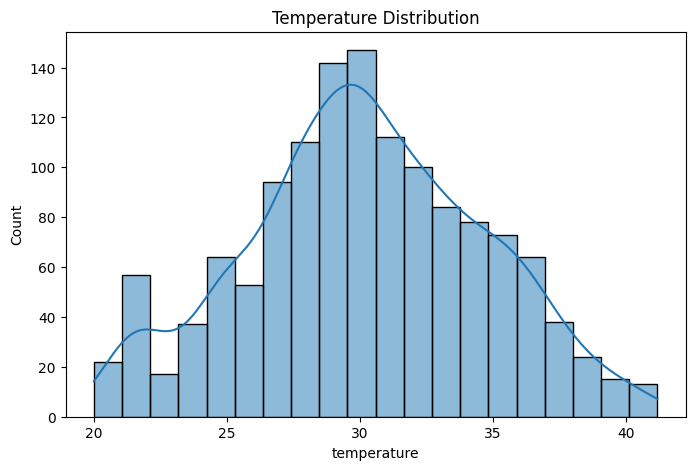

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    weather_df["temperature"],
    kde=True
)

plt.title(
    "Temperature Distribution"
)

plt.show()

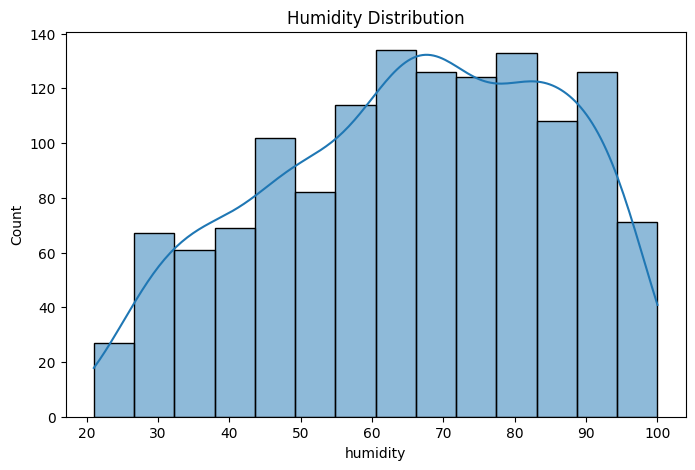

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    weather_df["humidity"],
    kde=True
)

plt.title(
    "Humidity Distribution"
)

plt.show()

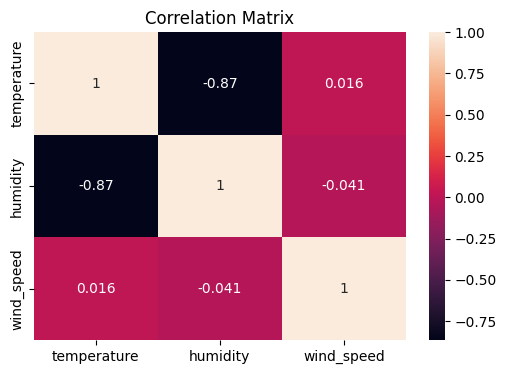

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    weather_df[
        [
            "temperature",
            "humidity",
            "wind_speed"
        ]
    ].corr(),
    annot=True
)

plt.title(
    "Correlation Matrix"
)

plt.show()